In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports


# Testing some quality control stuff

In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [60]:
df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df = dsp.preprocess(
    df,
    only_trials=False,
    combine_time_bins=False, 
    repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'GPe_spikes'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 53999 in trial: free and id: 668, inserting NaN.
Extending index to 53989 in trial: free and id: 668, inserting NaN.
Extending index to 53990 in trial: free and id: 668, inserting NaN.
Extending index to 53991 in trial: free and id: 668, inserting NaN.
Extending index to 53992 in trial: free and id: 668, inserting NaN.
Extending index to 53993 in trial: free and id: 668, inserting NaN.
Extending index to 53994 in trial: free and id: 668, inserting NaN.
Extending index to 53995 in trial: free and id: 668, inserting NaN.
Extending index to 53996 in trial: free and id: 668, inserting NaN.
Extending index to 53997 in trial: free and id: 668, inserting NaN.
Extending index to 53998 in trial: free and id: 668, inserting NaN.
Extending index to 53999 in trial: free and id: 668, inserting NaN.
['all_spikes', 'SSp_spik

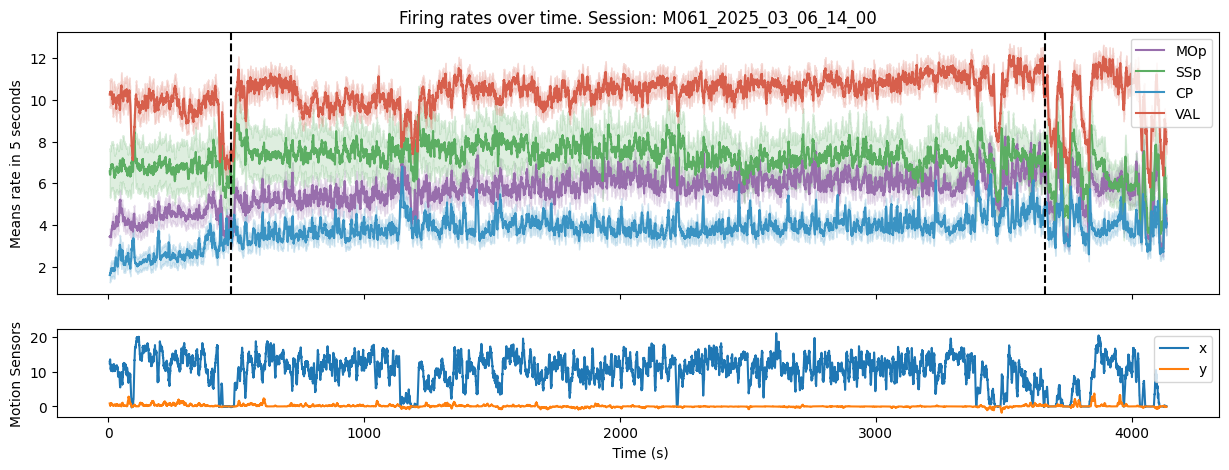

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5), sharex='all', gridspec_kw={'height_ratios': [3, 1]})
areas=["MOp", "SSp", "CP", "VAL"]

window = 5 # seconds
for area in areas:
    all_rates = np.concatenate(df[f"{area}_rates"].values, axis=0)
    means, time_bins = dsp.moving_window_mean(all_rates, int(window / Params.BIN_SIZE))
    vizutils.shaded_errorbar(ax[0], x=time_bins * Params.BIN_SIZE, y=means, errorStat=scipy.stats.sem, 
                    color=getattr(colors, f"{area}_light", "k"),
                    label=area
                    )
    
all_motion_sensor_x = np.concatenate(df[f"values_MotSen1_X"].values, axis=0)
all_motion_sensor_y = np.concatenate(df[f"values_MotSen1_Y"].values, axis=0)

motion_sensor_means_x, _ = dsp.moving_window_mean(all_motion_sensor_x, int(window / Params.BIN_SIZE))
motion_sensor_means_y, _ = dsp.moving_window_mean(all_motion_sensor_y, int(window / Params.BIN_SIZE))

ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_x, label='x')
ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_y, label='y')
ax[1].set_ylabel(f'Motion Sensors')
ax[1].legend()


ax[0].set_ylabel(f'Means rate in {window} seconds')
ax[1].set_xlabel(f' Time (s)')
ax[0].axvline(x=480, color="k", linestyle="--")
ax[0].axvline(x=3660, color="k", linestyle="--")
ax[0].set_title(f'Firing rates over time. Session: {session}')
ax[0].legend()

In [32]:
df.bin_size.values[0]

0.01

In [36]:
def compute_moving_window_mean_on_array(df, signal, window_s):
    arr = np.concatenate(df[signal].values, axis=0)
    means, time_bins = dsp.moving_window_mean(arr, int(window_s / df.bin_size.values[0]))
    return means, time_bins

def plot_frs_and_sensors_moving_window(df, areas, sensors=['values_MotSen1_X', 'values_MotSen1_Y'], window_s=5, figsize=(15, 5)):
    fig, ax = plt.subplots(2, 1, figsize=figsize, sharex='all', gridspec_kw={'height_ratios': [3, 1]})
    for area in areas:
        fr_means, time_bins = compute_moving_window_mean_on_array(df, f'{area}_rates', window_s=window_s)
        vizutils.shaded_errorbar(
            ax[0], 
            x=time_bins * df.bin_size.values[0], 
            y=fr_means, 
            errorStat=scipy.stats.sem, 
            color=getattr(colors, f"{area}_light", "k"),
            label=area
        )
    ax[0].set_ylabel('Firing rate (Hz)')
    
    for sensor in sensors:
        sensor_means, time_bins = compute_moving_window_mean_on_array(df, sensor, window_s=window_s)
        ax[1].plot(
            time_bins * df.bin_size.values[0], 
            sensor_means, 
            label=sensor
        )
    ax[0].legend()
    ax[1].set_ylabel('Mot. Sensor')
    ax[1].set_xlabel('Time (s)')
    plt.suptitle(f'Firing rates and motion sensors in {window_s} second window')

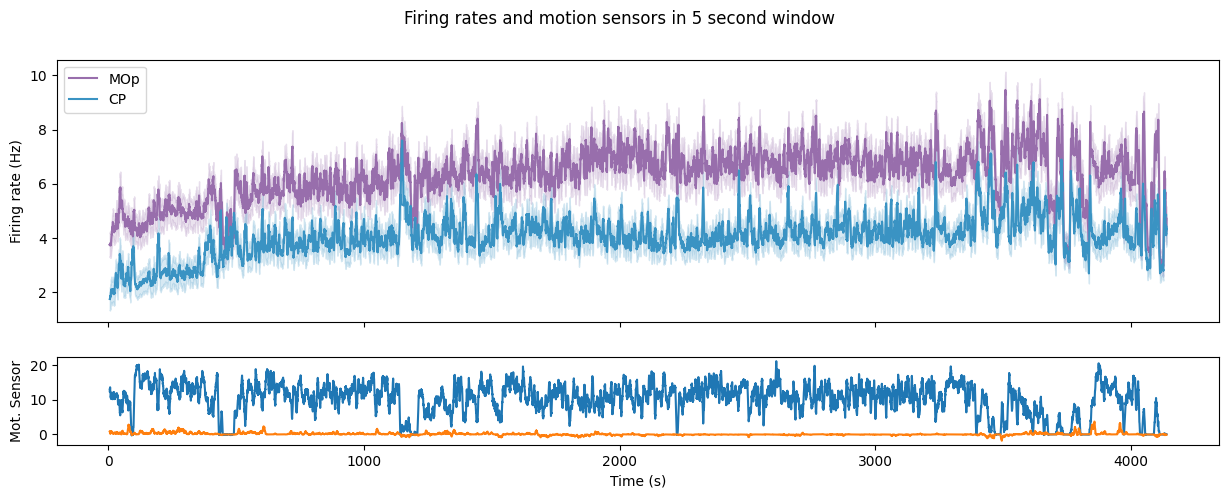

In [37]:
plot_frs_and_sensors_moving_window(df, areas=['MOp', 'CP'])

In [ ]:
def decode_sol_dir_pcs_and_bhv(td, areas=['bhv', 'MOp', 'SSp', 'CP', 'VAL'], step_bin=2):
    scores = {}
    targets = td.values_Sol_direction.values.tolist() 
    for area in areas:
        if area != 'bhv':
            scores[area], times = decode.moving_window_decoding(
                np.stack(td[f"{area}_rates_pca"]),
                targets,
                window_length_bin=10,
                step_bin=step_bin,
                cv=5
            )
        else:
            scores[area], times = decode.moving_window_decoding(
                np.stack(td[area]),
                targets,
                window_length_bin=10,
                step_bin=step_bin,
                cv=5
            )
    return scores, times

In [52]:
def plot_decoding_sol_dir(td, areas):
    td = pyal.select_trials(td, td.trial_name == 'trial')
    td = dt.add_pca_df(td)
    try:
        td = dt.add_bhv(td)
        areas = areas + ['bhv']
    except:
        print('No behaviour found')
    td = dt.remove_trials_wo_motion_before_event(td, 'idx_motion', 'idx_sol_on')
    perturb_td = pyal.restrict_to_interval(td, 'idx_sol_on', rel_start = -100, rel_end= 150)


    scores, times = decode_sol_dir_pcs_and_bhv(perturb_td, areas=areas)

    fig, ax = plt.subplots()
    for area in areas:
        line, _ = vizutils.shaded_errorbar(ax, times-1, scores[area], 
                                        errorStat=scipy.stats.sem, label=area, color=getattr(colors, f"{area}_light"))
        # ax.axvline(x=times[np.argmax(scores[area].mean(axis=-1))]-1, color=getattr(colors, f"{area}_light"), linestyle='dashed')
        peak_time = times[np.argmax(scores[area].mean(axis=-1))]-1
        ax.plot(peak_time, 0.47, marker='o', color=getattr(colors, f"{area}_light"))

    ax.axvline(x=0, color='r', linestyle='dashed', label='perturb')
    ax.axhline(y=1/12, color='k', linestyle='dashed', label='chance')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Decoding Accuracy (%)')
    # ax.legend()
    ax.set_ylim([0, 0.55])
    ax.set_xlim([-0.25, 1])

Dropped 11 of 333 rows (3.30%).


100%|██████████| 242/242 [00:03<00:00, 69.66it/s]


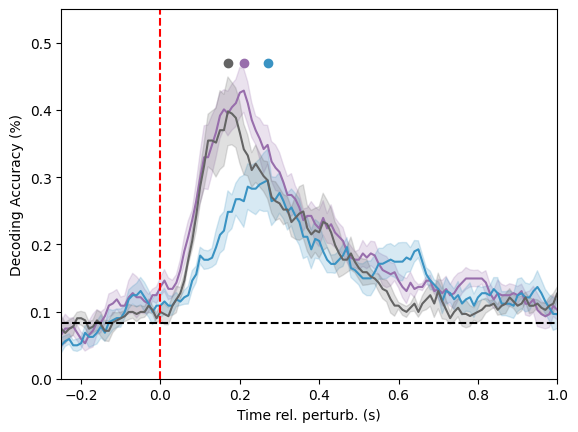

In [53]:
plot_decoding_sol_dir(df, areas=['MOp', 'CP'])

# Try with refactored functions

In [4]:
reports.run_quality_control_on_session(
    data_dir='/data/bnd-data/raw/',
    session='M061_2025_03_06_14_00'
)

KeyboardInterrupt: 

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'idx_motion', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 41999 in trial: free and id: 1003, inserting NaN.
Extending index to 41999 in trial: free and id: 1003, inserting NaN.
['SSp_spikes', 'all_spikes', 'VAL_spikes', 'MOs_spikes', 'CP_spikes', 'MOp_spikes']
Resulting SSp_spikes ephys data shape is (NxT): (90, 48000)
Resulting all_spikes ephys data shape is (NxT): (54, 48000)
Resulting VAL_spikes ephys data shape i

100%|██████████| 242/242 [00:03<00:00, 60.92it/s]
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/data/poetryenvs/earthquake-anal

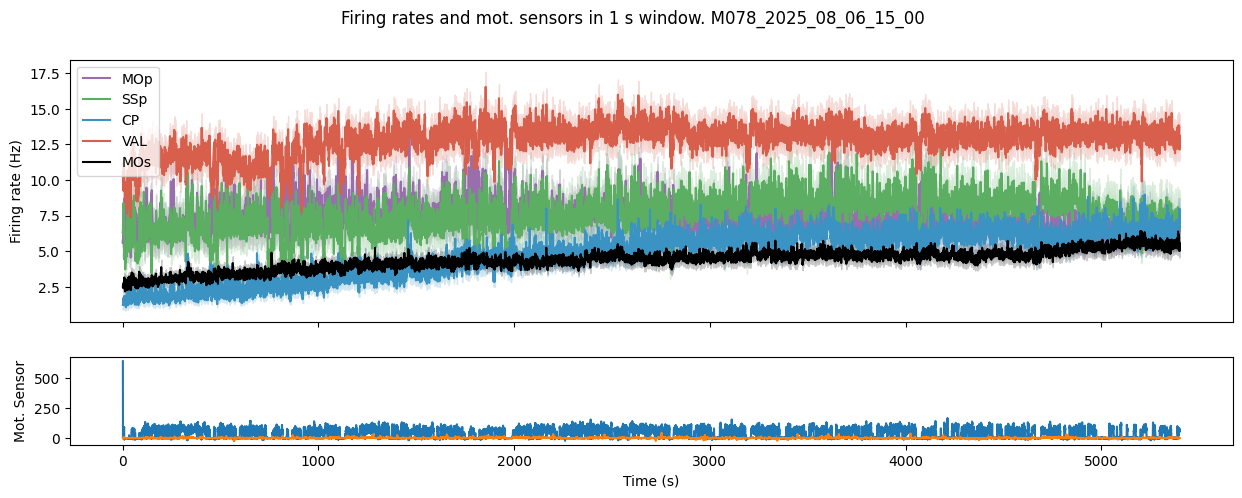

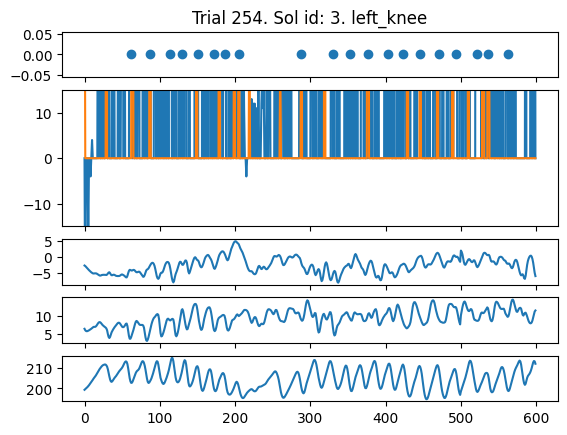

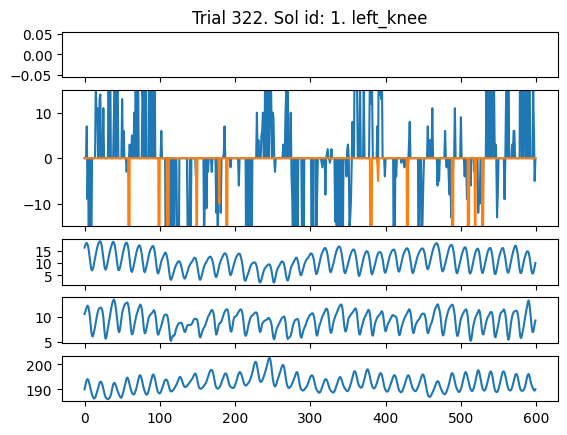

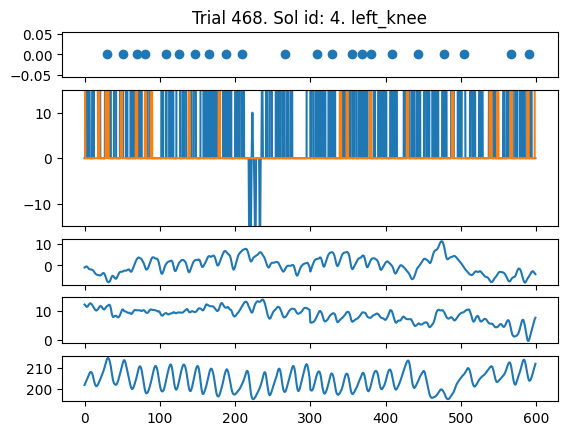

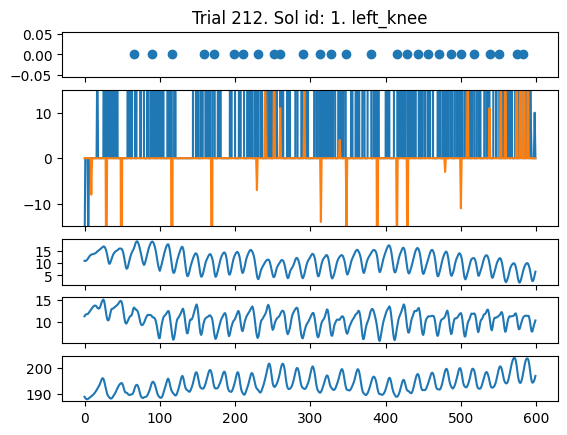

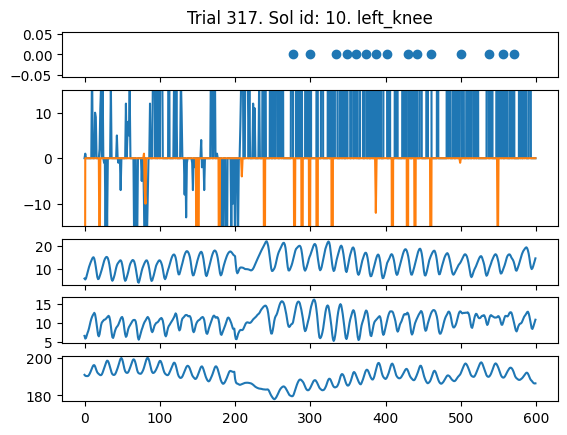

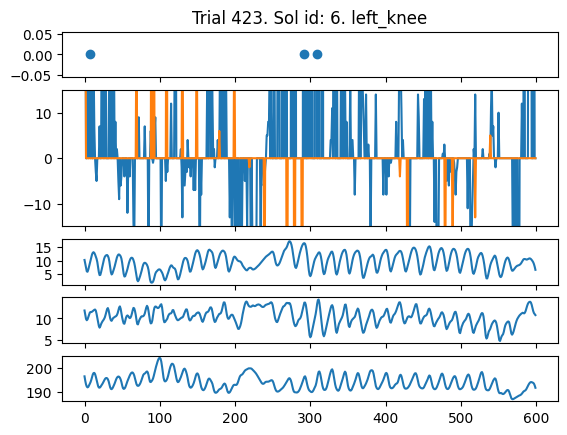

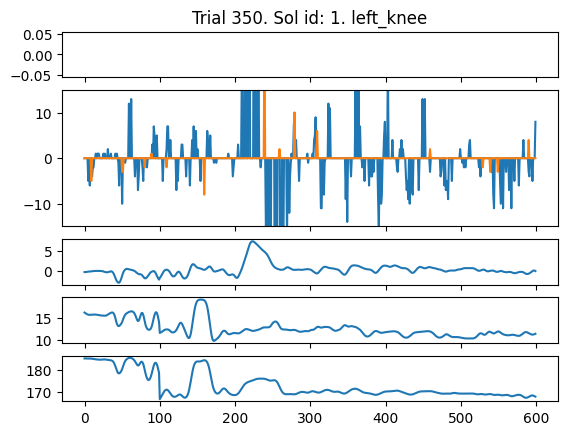

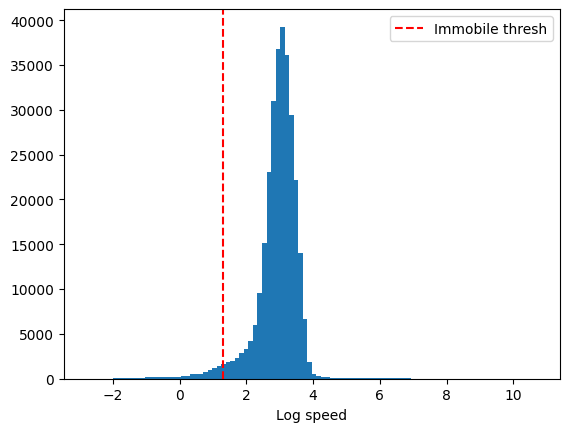

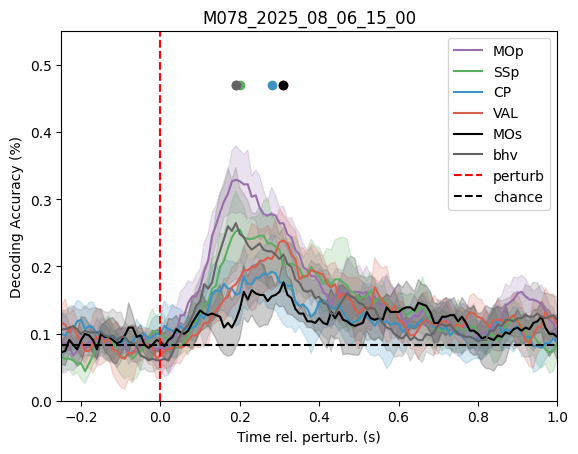

In [5]:
sessions = [
    # ('M061_2025_03_04_10_00', 2),
    # ('M061_2025_03_05_14_00', 2),
    # ('M061_2025_03_06_14_00', 1),
    # ('M063_2025_03_12_14_00', None),
    # ('M063_2025_03_13_14_00', 7),
    # ('M063_2025_03_14_15_30', None),
    # ('M062_2025_03_19_14_00', 6),
    # ('M062_2025_03_20_14_00', 0.5),
    # ('M062_2025_03_21_14_00', 2),
    # ('M078_2025_08_05_15_30', None),
    ('M078_2025_08_06_15_00', 3),
    # ('M078_2025_08_07_13_30', 2),
    # ('M086_2025_12_09_16_00', 0.75),
    # ('M086_2025_12_10_15_00', 0.75)

]

for session, p in sessions:
    reports.run_quality_control_on_session(
        data_dir='/data/bnd-data/raw/',
        session=session,
        p=p
    )